# Config

In [11]:
import pandas as pd
import openpyxl
import re
import ftfy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR
from plots import plot_satisfaction_bar, plot_target_correlations, analyze_ppe_usage, usage_summary
pd.set_option('future.no_silent_downcasting', True)

# Read data

In [12]:
file_path = PROCESSED_DATA_DIR / "survey_processed_data.xlsx"

datos_df = pd.read_excel(file_path, sheet_name="Datos")
print("Datos",datos_df.shape)

labels_df = pd.read_excel(file_path, sheet_name="Labels")
print("Labels",labels_df.shape)

variables_df = pd.read_excel(file_path, sheet_name="Variables")
print("Variables",variables_df.shape)

# codes_df = pd.read_excel(file_path, sheet_name="Codes")
# print("Codes",codes_df.shape)

Datos (1813, 520)
Labels (1813, 514)
Variables (514, 5)


# Plots

### PPE usage

In [13]:


# 1. Define Standard Mappings
safety_map = {4.0: 'Always', 3.0: 'Most times', 2.0: 'Sometimes', 1.0: 'Never'}
safety_order = ["Always", "Most times", "Sometimes", "Never"]
ppe_rename = {'use_jacket': 'Jacket', 'use_leg': 'Leg Protection', 'use_helmet': 'Helmet'}

# 2. Create Categorical Columns
datos_df['use_jacket'] = datos_df['P13_recoded'].map(safety_map)
datos_df['use_leg'] = datos_df['P17_recoded'].map(safety_map)
datos_df['use_helmet'] = datos_df['P7_3_recoded'].map(safety_map)

# 3. Filter Ownership (P8#1 for Helmet)
datos_df.loc[datos_df['P8#1'] == 0, 'use_helmet'] = pd.NA

# 4. Melt and Clean for Plotting
ppe_df = (
    datos_df.melt(id_vars=['City'], value_vars=list(ppe_rename.keys()), 
                  var_name='PPE_Type', value_name='Usage')
    .dropna(subset=['Usage'])
)
ppe_df['PPE_Type'] = pd.Categorical(ppe_df['PPE_Type'].map(ppe_rename), 
                                   categories=['Helmet', 'Jacket', 'Leg Protection'], ordered=True)
ppe_df['Usage'] = pd.Categorical(ppe_df['Usage'], categories=safety_order, ordered=True)

# Define a Shared Theme to reduce repetitive code
shared_theme = theme_minimal() + theme(
    text=element_text(family='Times New Roman', size=18),
    plot_title=element_text(hjust=0.5, size=24, fontweight='bold'),
    strip_text=element_text(size=20, fontweight='bold'),
    axis_text=element_text(size=16),
    axis_title=element_text(size=18, fontweight='bold'),
    legend_text=element_text(size=16),
    legend_title=element_text(size=18, fontweight='bold'),
    legend_position="top",
    figure_size=(8, 12)
)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 12 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\refined_ppe_usage.png


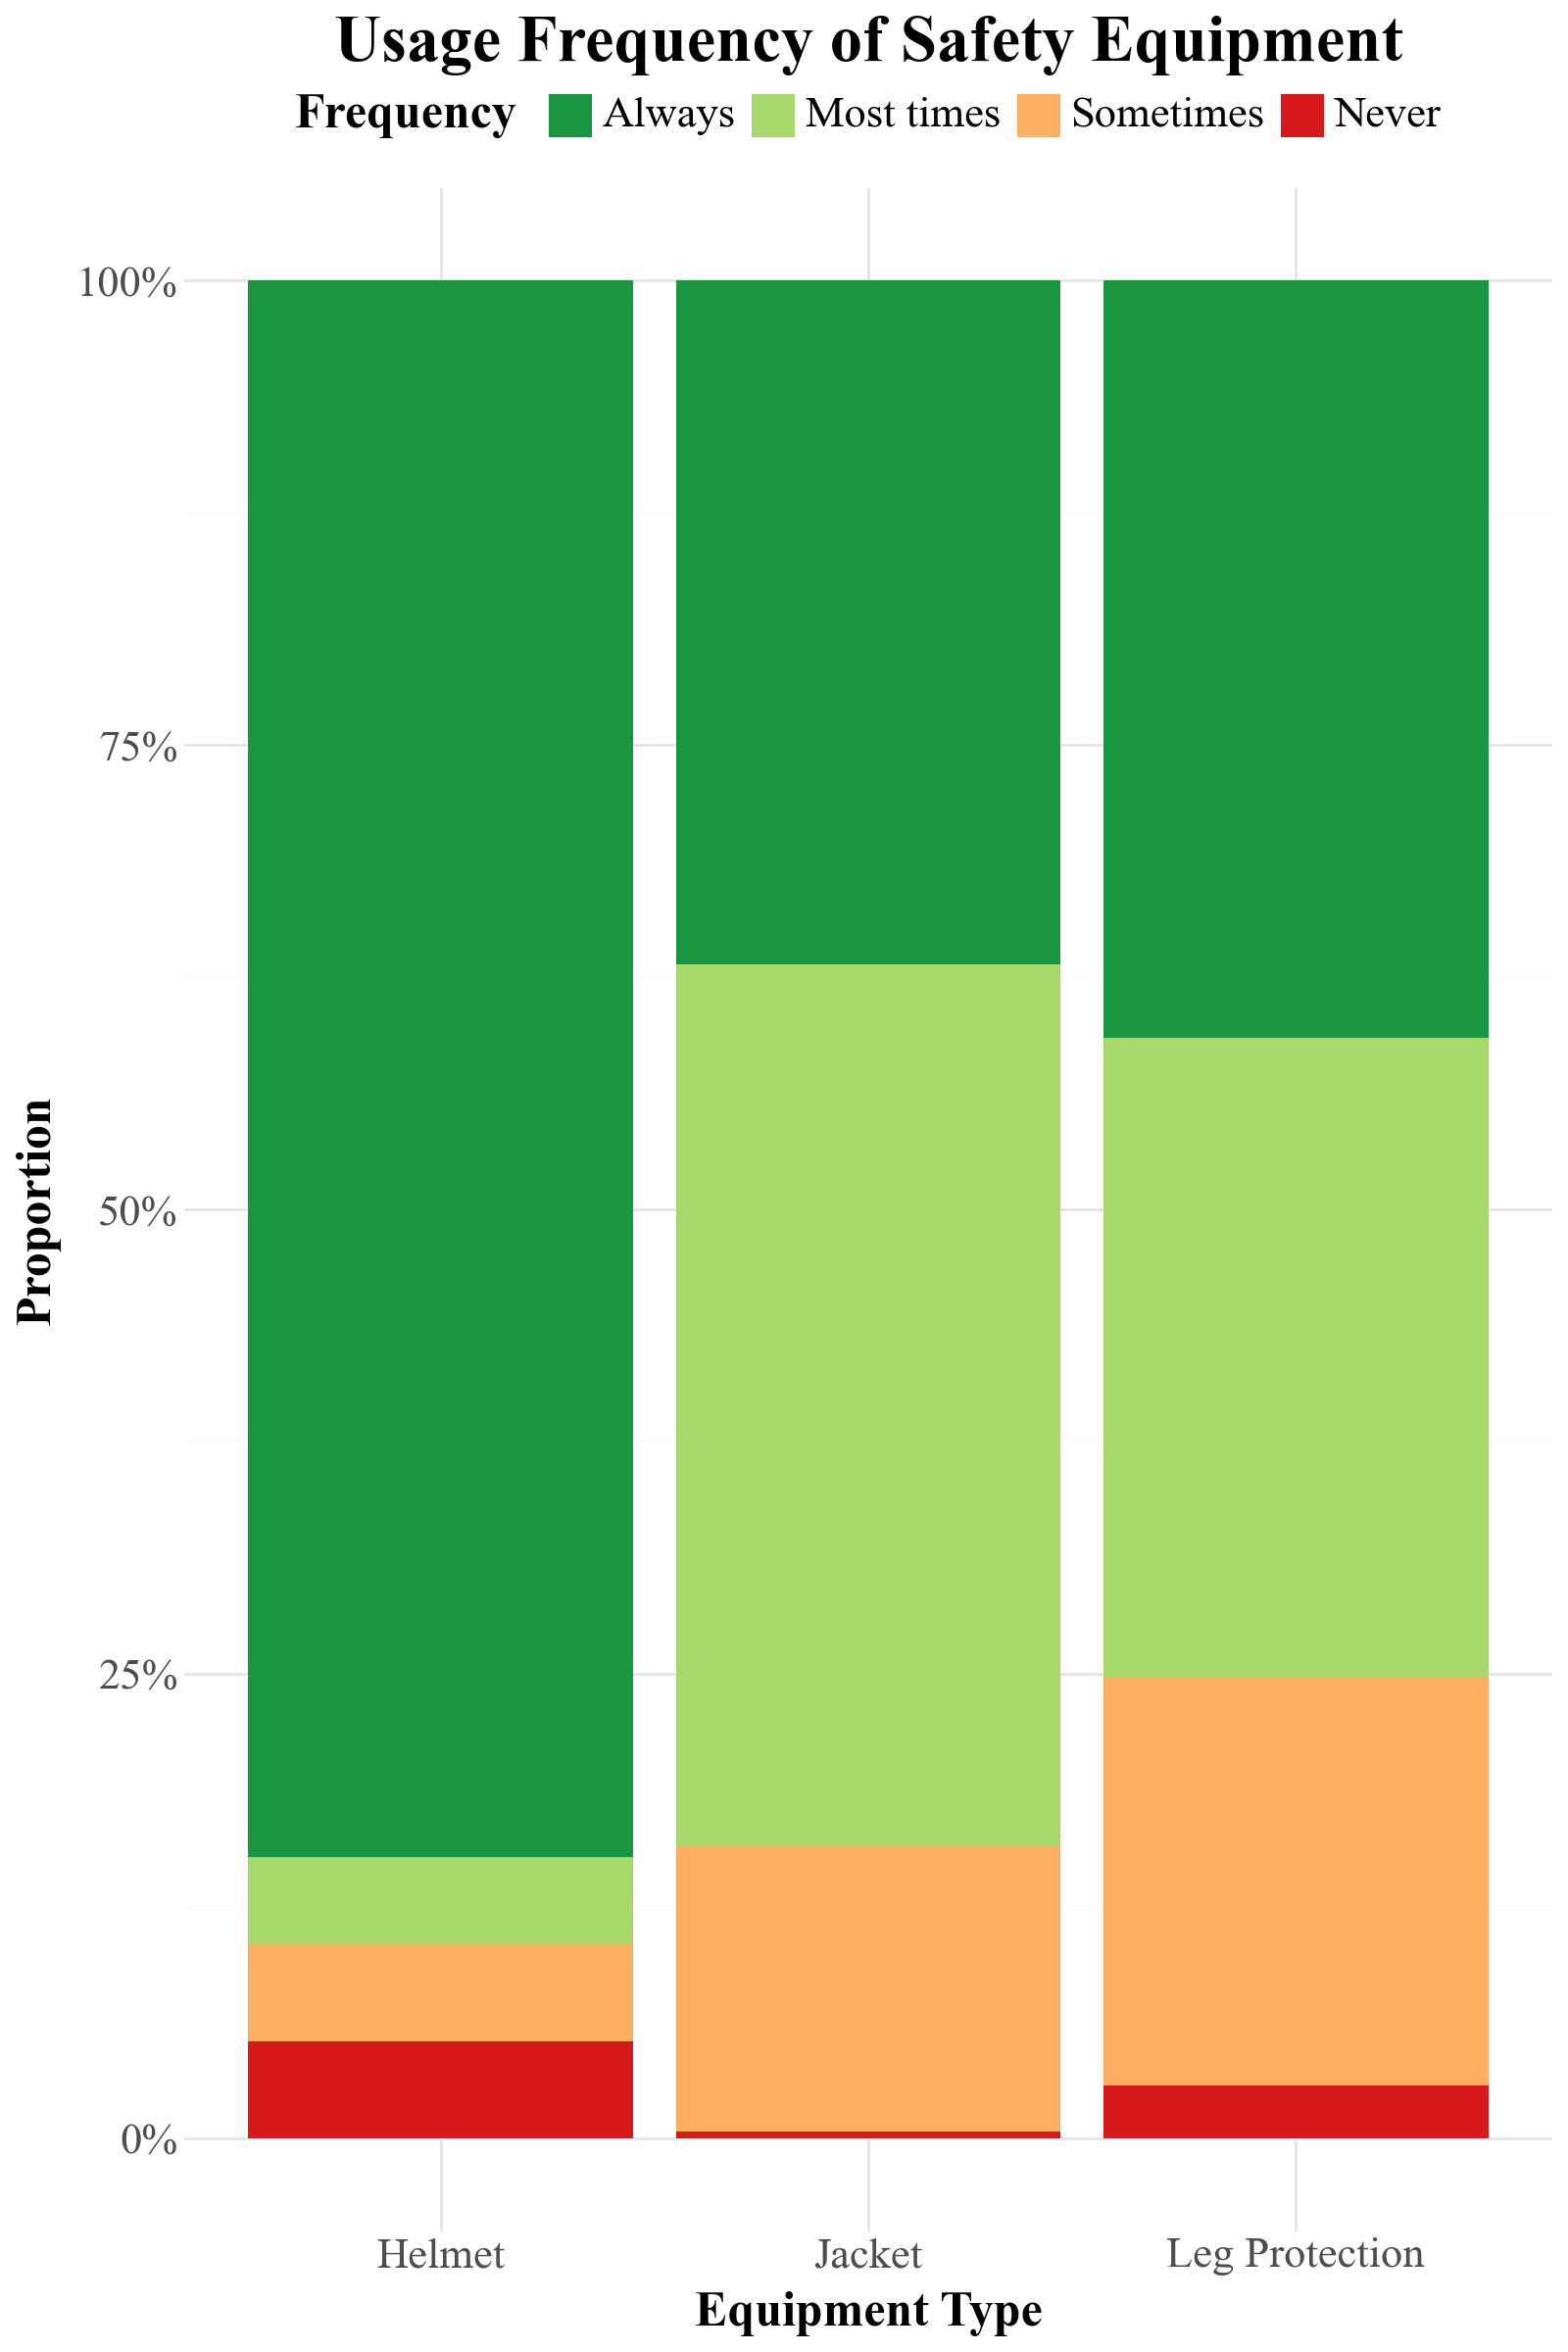

In [14]:
plot_global = (
    ggplot(ppe_df, aes(x='PPE_Type', fill='Usage'))
    + geom_bar(position="fill")
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(title="Usage Frequency of Safety Equipment", x="Equipment Type", y="Proportion", fill="Frequency")
    + shared_theme
)
plot_global.save(FIGURES_DIR / "refined_ppe_usage.png", dpi=300)
plot_global

PPE_Type
Jacket            546
Leg Protection    314
Helmet              0
Name: count, dtype: int64


c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 12 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\refined_ppe_usage_x_city_no_helmet.png


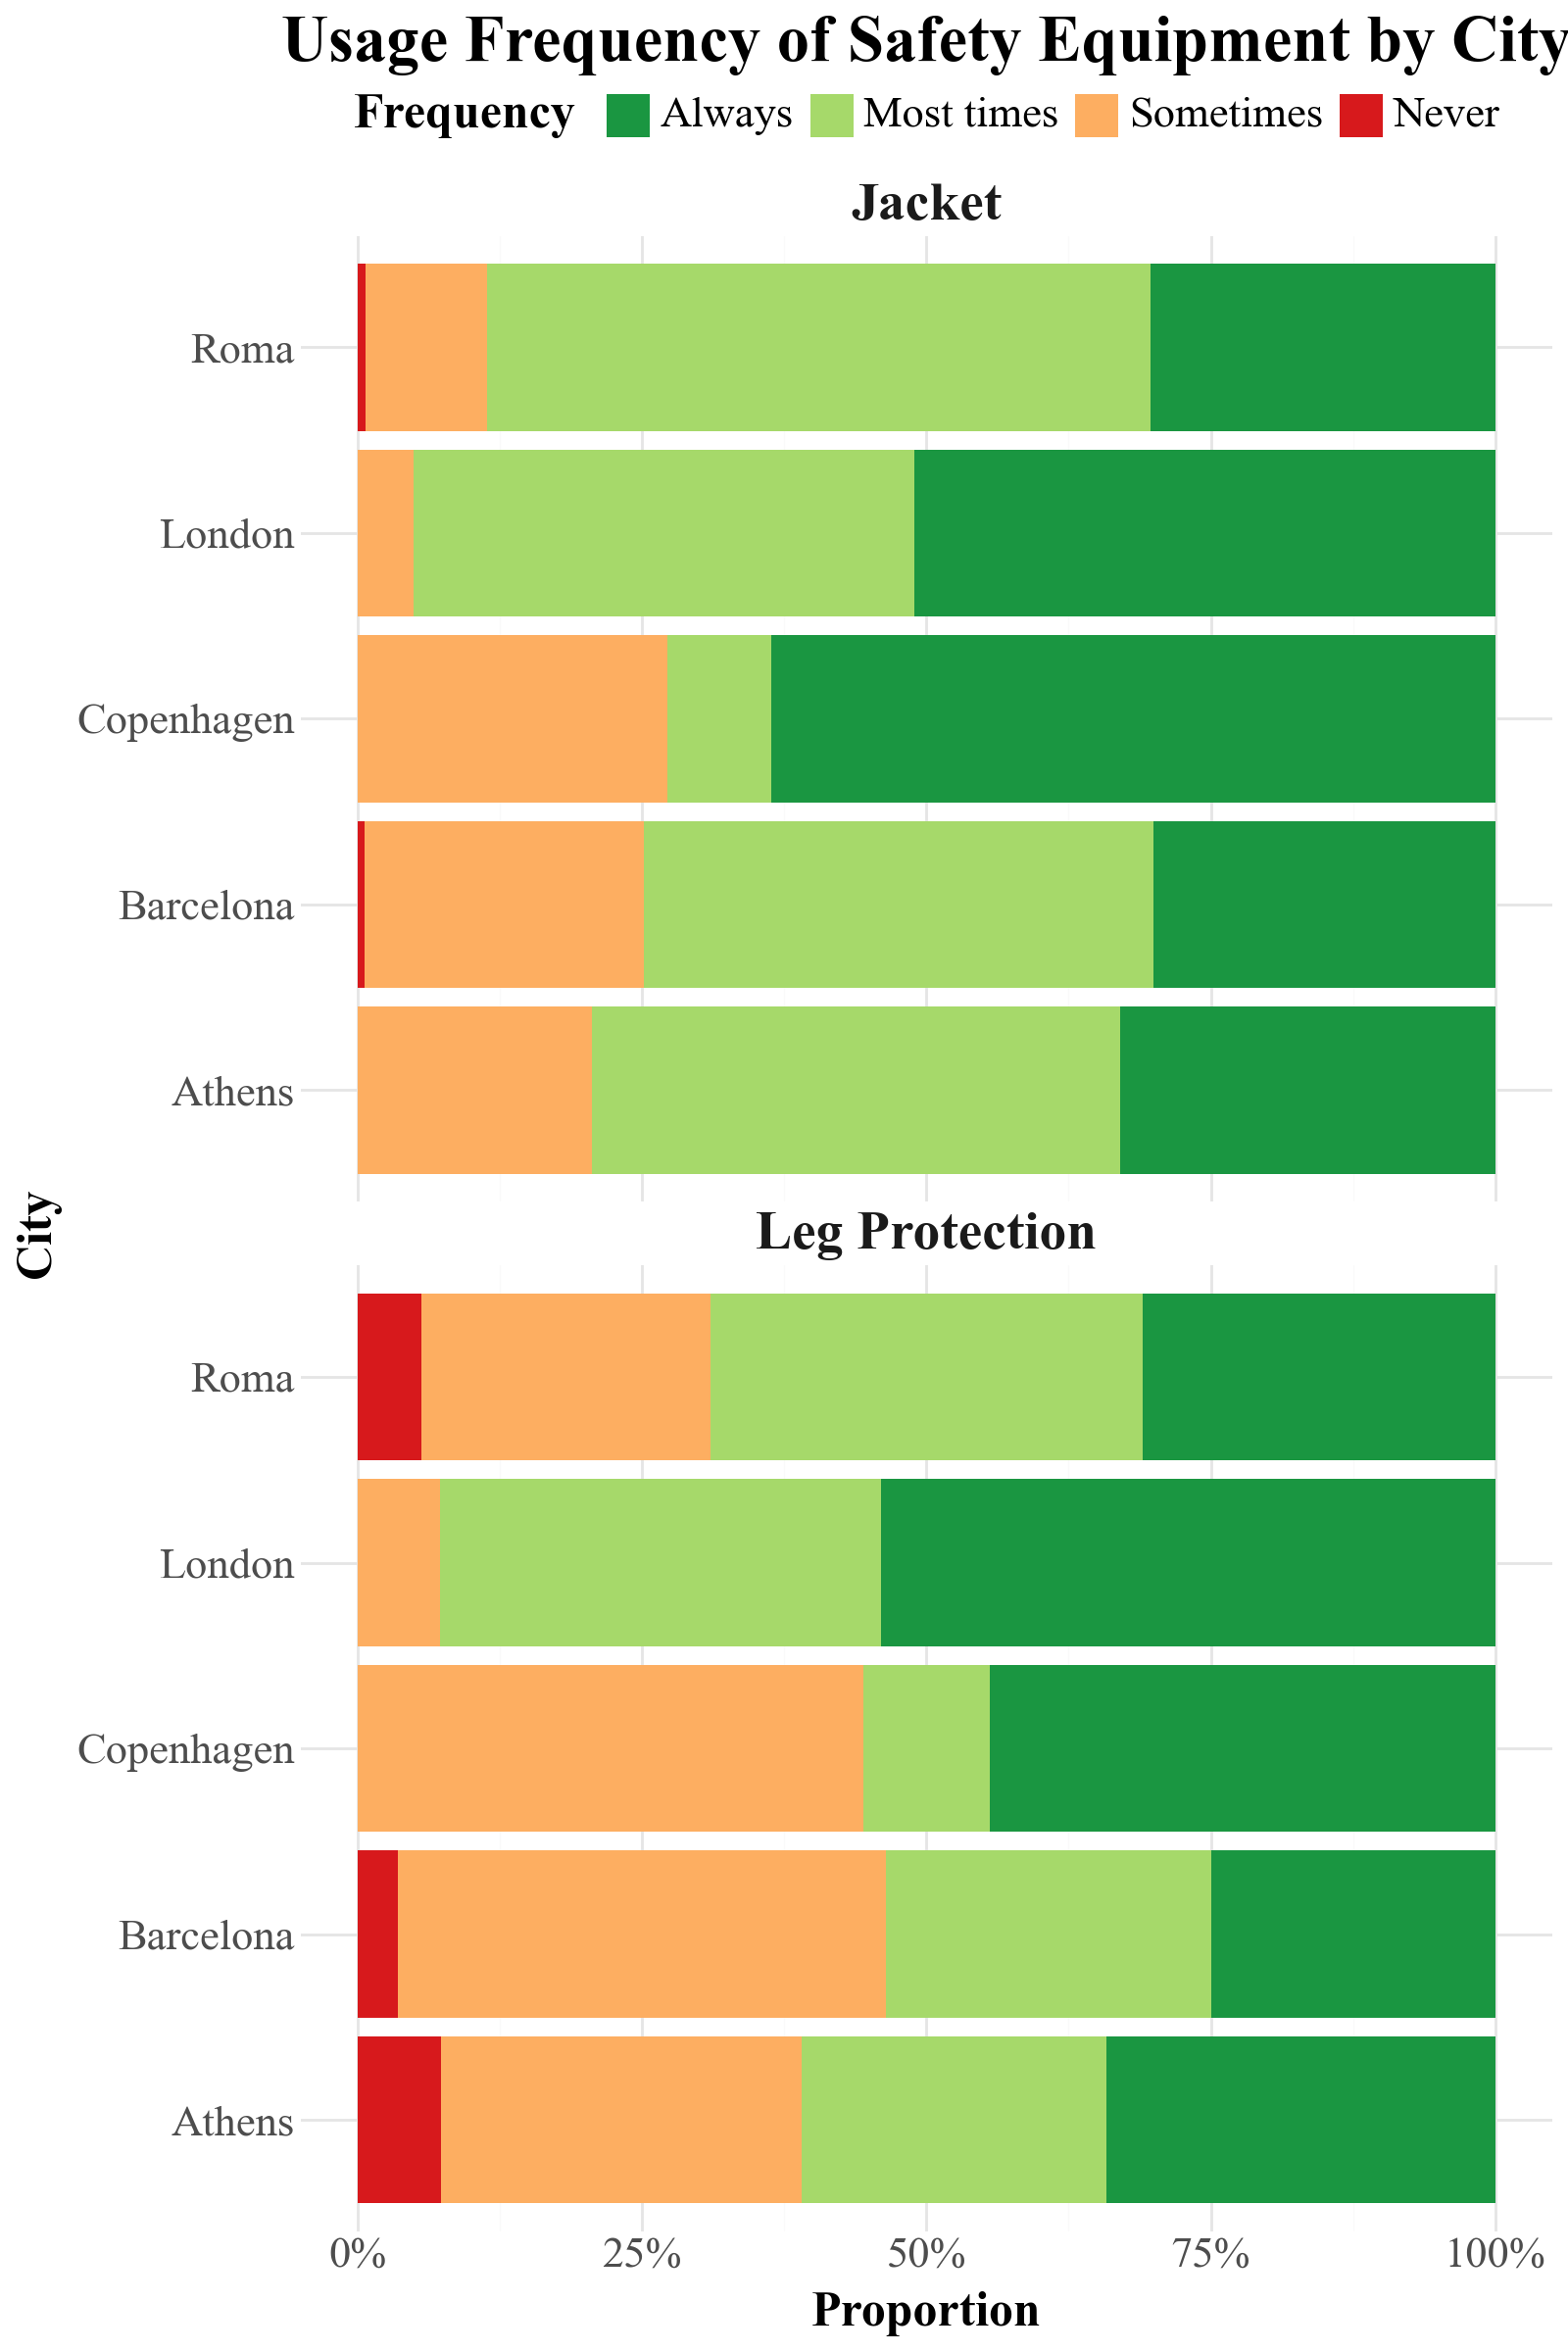

In [21]:
ppe_df_without_hermet = ppe_df[ppe_df["PPE_Type"]!="Helmet"]
print(ppe_df_without_hermet["PPE_Type"].value_counts())

plot_city = (
    ggplot(ppe_df_without_hermet, aes(x='City', fill='Usage'))
    + geom_bar(position="fill")
    + coord_flip() 
    + facet_wrap('~PPE_Type', ncol=1) 
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(title="Usage Frequency of Safety Equipment by City", x=None, y="Proportion", fill="Frequency")
    + shared_theme
)
plot_city.save(FIGURES_DIR / "refined_ppe_usage_x_city_no_helmet.png", dpi=300)
plot_city

PPE_Type
Leg Protection    314
Helmet              0
Jacket              0
Name: count, dtype: int64


c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 12 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\refined_ppe_usage_x_city_only_leg.png


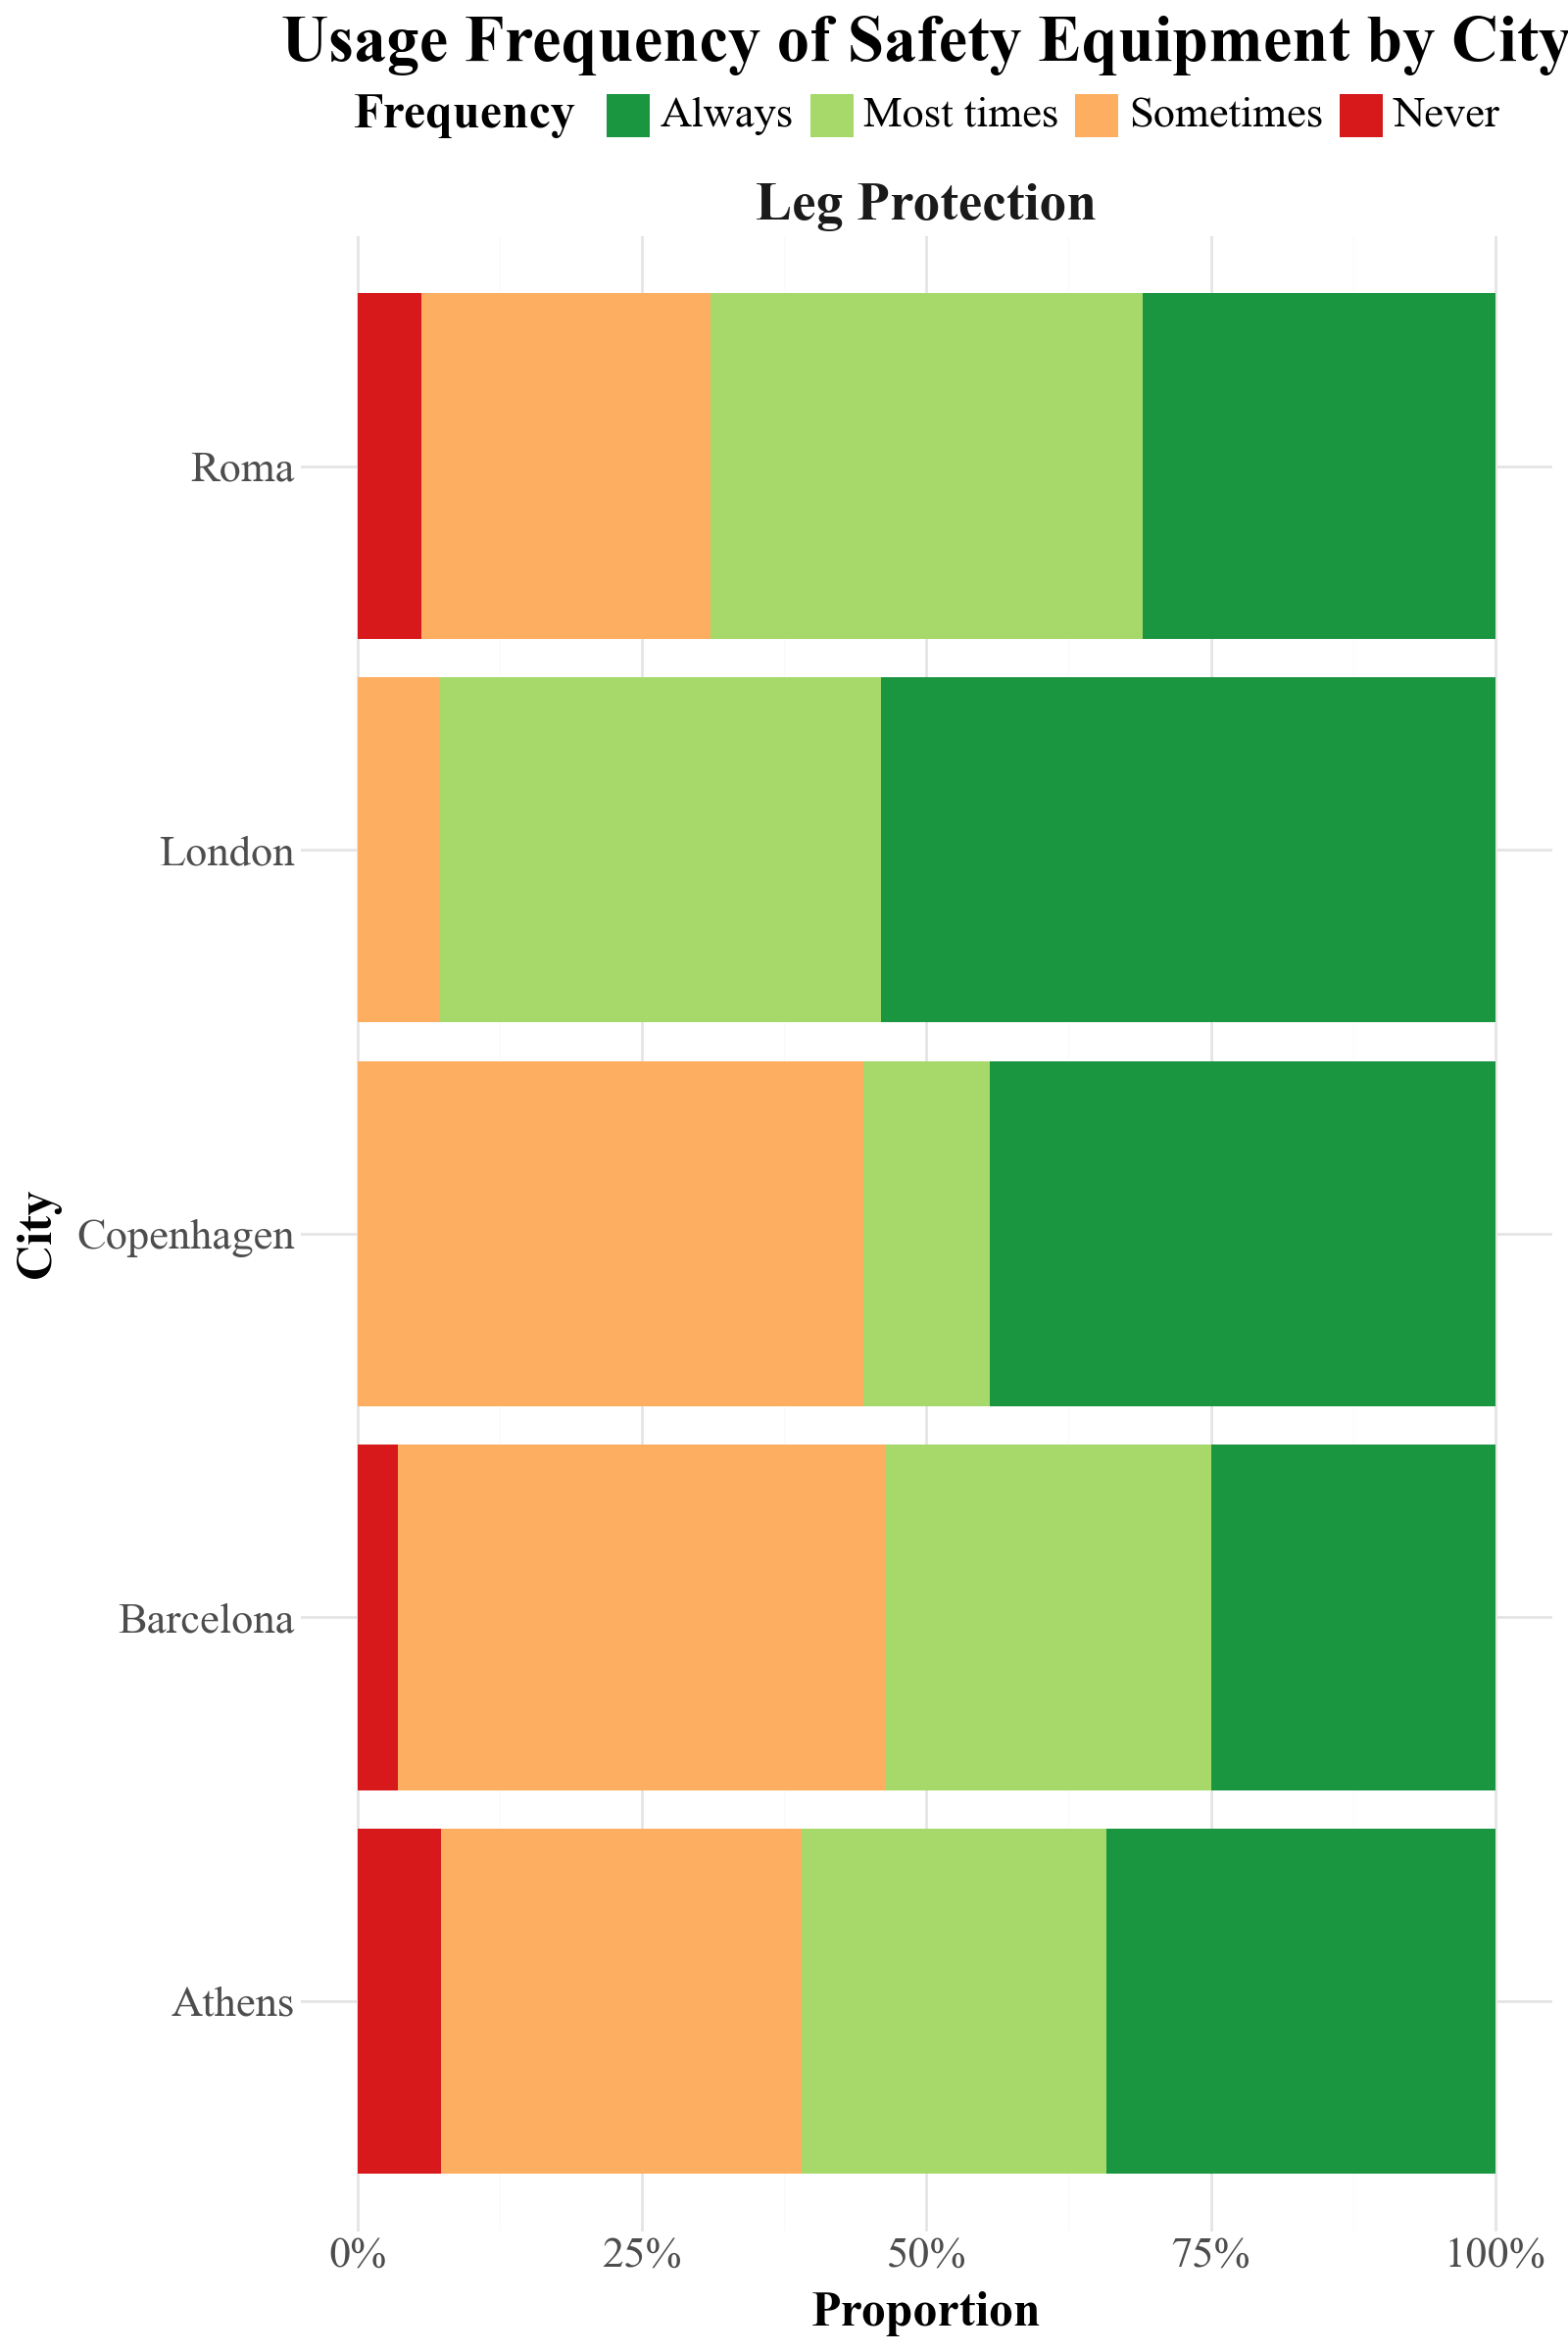

In [23]:

ppe_df_leg_only = ppe_df[ppe_df["PPE_Type"]=="Leg Protection"]
print(ppe_df_leg_only["PPE_Type"].value_counts()
)

plot_city = (
    ggplot(ppe_df_leg_only, aes(x='City', fill='Usage'))
    + geom_bar(position="fill")
    + coord_flip() 
    + facet_wrap('~PPE_Type', ncol=1) 
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(title="Usage Frequency of Safety Equipment by City", x=None, y="Proportion", fill="Frequency")
    + shared_theme
)
plot_city.save(FIGURES_DIR / "refined_ppe_usage_x_city_only_leg.png", dpi=300)
plot_city

# Save data